# CSE 475 - Assignment 02
## Group Information

| Field | Details |
|----------------------------|----------------------------------------------|
| Group ID | Group H |
| Student 1 Name | Benazir Meem |
| Student 1 ID | 2022-3-60-169 |
| Student 2 Name | Asifa Akter Liya |
| Student 2 ID | 2022-3-60-186 |
| Student 3 Name | Riya Akter |
| Student 3 ID | 2022-3-60-176 |
| Student 4 Name | Sadia Afrin |
| Student 4 ID | 2022-2-60-088 |
| Notebook Type | BYOL Notebook |
| Backbone Used | EfficientNet-B3 (from Assignment 01 checkpoint) |
| Assignment 01 Best Acc | 64.67% (EfficientNet-B3, non-ResNeXt best) |
| Dataset Name (Kaggle) | /kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset |
| Dataset Source | Eggplant Leaf Disease Classification Dataset |
| Dataset Source Link | https://data.mendeley.com/datasets/pvsv534ccg/1 |
| Submission Date | DD Month 2026 |

## Lab Assignment 02 - BYOL

This notebook covers Task 1, Task 2, Task 4a-4b for BYOL, and Task 5 ablation.

**Important:** ResNeXt is prohibited. Use the EfficientNet-B3 backbone weights from your Assignment 01 checkpoint dataset.

## 1. Global Configuration

In [1]:
import torch
import random
import numpy as np

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONFIG = {
    "batch_size": 32,
    "epochs": 30,
    "lr": 3e-4,
    "weight_decay": 1e-6,
    "image_size": 224,
    "embedding_dim": 1536,
    "projection_dim": 256,
    "hidden_dim": 4096,
    "num_classes": 11,
    "dataset_path": "/kaggle/input/datasets/asifaakterliya/cse475-grouph-dataset/Eggplant Dataset",
    "checkpoint_path": "/kaggle/input/datasets/asifaakterliya/grouph-efficientnetb3-checkpoint/efficientnet_b3_best.pth",
}

print("==========================")
print("GLOBAL CONFIGURATION")
print("==========================")
print(f"Batch Size: {CONFIG['batch_size']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Learning Rate: {CONFIG['lr']}")
print(f"Weight Decay: {CONFIG['weight_decay']}")
print(f"Image Size: {CONFIG['image_size']}")
print(f"Backbone Embedding Dim: {CONFIG['embedding_dim']}")
print(f"Dataset Path: {CONFIG['dataset_path']}")
print(f"Checkpoint Path: {CONFIG['checkpoint_path']}")
print(f"Device: {DEVICE}")
print("==========================")
print("✔ Random seed set successfully")
print(f"✔ Device detected ({'GPU' if DEVICE == 'cuda' else 'CPU'})")

GLOBAL CONFIGURATION
Batch Size: 32
Epochs: 30
Learning Rate: 0.0003
Weight Decay: 1e-06
Image Size: 224
Backbone Embedding Dim: 1536
Dataset Path: /kaggle/input/datasets/asifaakterliya/cse475-grouph-dataset/Eggplant Dataset
Checkpoint Path: /kaggle/input/datasets/asifaakterliya/grouph-efficientnetb3-checkpoint/efficientnet_b3_best.pth
Device: cuda
✔ Random seed set successfully
✔ Device detected (GPU)


## Setup and Imports


In [2]:
# Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.models as models

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

cuda_available = torch.cuda.is_available()
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    device_status = f"GPU ({gpu_name})"
else:
    gpu_name = None
    device_status = "CPU"

print("==========================")
print("ENVIRONMENT STATUS")
print("==========================")
print(f"✔ PyTorch version: {torch.__version__}")
print(f"✔ Torchvision version: {torchvision.__version__}")
print(f"✔ CUDA Available: {cuda_available}")
print(f"✔ Device: {device_status}")
if cuda_available:
    print(f"✔ GPU name: {gpu_name}")
else:
    print("✔ Running on CPU")
print("✔ All imports loaded successfully")
print("==========================")

ENVIRONMENT STATUS
✔ PyTorch version: 2.10.0+cu128
✔ Torchvision version: 0.25.0+cu128
✔ CUDA Available: True
✔ Device: GPU (Tesla T4)
✔ GPU name: Tesla T4
✔ All imports loaded successfully


## Task 1 - Dataset EDA and Augmentation Visualisation


# Load Dataset

In [3]:
base_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

dataset = ImageFolder(CONFIG["dataset_path"], transform=base_transform)
sample_x, sample_y = dataset[0]

print("------------------------------")
print("Dataset Information")
print("------------------------------")
print("✔ Dataset loaded successfully")
print(f"Total dataset size: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Class names: {dataset.classes}")
print(f"Sample tensor shape: {tuple(sample_x.shape)} | Label index: {sample_y}")
print("✔ Step completed: Dataset loading")

------------------------------
Dataset Information
------------------------------
✔ Dataset loaded successfully
Total dataset size: 2991
Number of classes: 11
Class names: ['Cercospora', 'Curl', 'FleaBeetles', 'HaddaBeetles', 'Healthy', 'LeafhopperJassids', 'MagnesiumDeficiency', 'PhomopsisBlight', 'TMV', 'TubacooCaterpillar', 'VerticilliumWilt']
Sample tensor shape: (3, 224, 224) | Label index: 0
✔ Step completed: Dataset loading


# Split (80/10/10)

In [4]:
total = len(dataset)

train_size = int(0.8 * total)
val_size = int(0.1 * total)
test_size = total - train_size - val_size

unlabeled_set, labeled_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print("------------------------------")
print("Split Information")
print("------------------------------")
print(f"Train split size (unlabelled): {len(unlabeled_set)}")
print(f"Validation split size (labelled): {len(labeled_set)}")
print(f"Test split size: {len(test_set)}")
print("✔ Step completed: Dataset split (80/10/10)")
print("✔ Confirmation: NO LABELS USED in BYOL training loop (labels are explicitly ignored as for img, _ in loader)")

------------------------------
Split Information
------------------------------
Train split size (unlabelled): 2392
Validation split size (labelled): 299
Test split size: 300
✔ Step completed: Dataset split (80/10/10)
✔ Confirmation: NO LABELS USED in BYOL training loop (labels are explicitly ignored as for img, _ in loader)


# Class Distribution

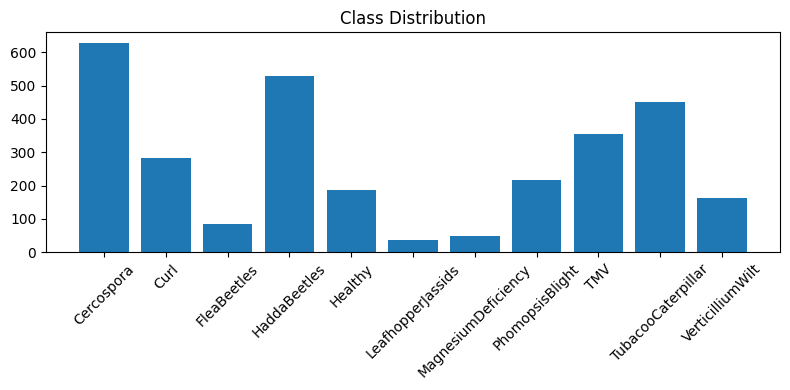

✔ Step completed: Class distribution visualization
Class counts: {0: 628, 1: 284, 2: 84, 3: 530, 4: 188, 5: 38, 6: 50, 7: 218, 8: 356, 9: 452, 10: 163}


In [5]:
from collections import Counter

labels = [label for _, label in dataset]
counts = Counter(labels)

plt.figure(figsize=(8, 4))
plt.bar(dataset.classes, [counts[i] for i in range(len(dataset.classes))])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("✔ Step completed: Class distribution visualization")
print(f"Class counts: {dict(counts)}")

# Augmentation Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


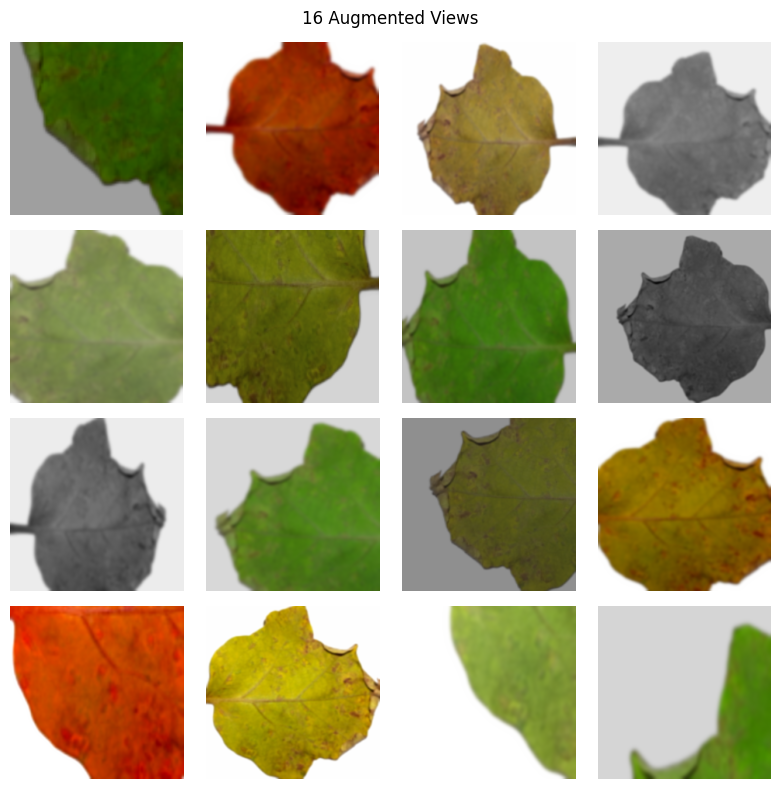

✔ Step completed: Augmentation visualization


In [6]:
augment = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(23),
])

img, _ = dataset[0]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(augment(img).permute(1, 2, 0))
    ax.axis("off")

plt.suptitle("16 Augmented Views")
plt.tight_layout()
plt.show()

print("✔ Step completed: Augmentation visualization")

## Task 2 - BYOL: Model Definition

# MLP

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=4096, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

print("✔ Step completed: MLP class definition")

✔ Step completed: MLP class definition


# Backbone

In [8]:
print("Loading EfficientNet-B3 backbone and checkpoint...")

backbone = models.efficientnet_b3(weights=None)
backbone.classifier = nn.Identity()

ckpt = torch.load(CONFIG["checkpoint_path"], map_location=DEVICE)
if isinstance(ckpt, dict):
    if "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    elif "model" in ckpt:
        ckpt = ckpt["model"]

cleaned_ckpt = {}
for key, value in ckpt.items():
    cleaned_key = key
    if cleaned_key.startswith("module."):
        cleaned_key = cleaned_key[len("module."):]
    if cleaned_key.startswith("backbone."):
        cleaned_key = cleaned_key[len("backbone."):]
    cleaned_ckpt[cleaned_key] = value

load_result = backbone.load_state_dict(cleaned_ckpt, strict=False)
backbone.to(DEVICE)

print(f"Missing keys: {len(load_result.missing_keys)}")
print(f"Unexpected keys: {len(load_result.unexpected_keys)}")
print(f"✔ Step completed: Backbone ready on {DEVICE}")

Loading EfficientNet-B3 backbone and checkpoint...
Missing keys: 0
Unexpected keys: 2
✔ Step completed: Backbone ready on cuda


# BYOL Class

In [9]:
import copy

class BYOL(nn.Module):
    def __init__(self, backbone):
        super().__init__()

        self.online_backbone = backbone
        self.target_backbone = copy.deepcopy(backbone)

        self.online_projector = MLP(1536)
        self.target_projector = MLP(1536)

        self.predictor = MLP(256)

        for p in self.target_backbone.parameters():
            p.requires_grad = False

    def forward(self, x1, x2):
        z1 = self.online_projector(self.online_backbone(x1))
        z2 = self.online_projector(self.online_backbone(x2))

        p1 = self.predictor(z1)
        p2 = self.predictor(z2)

        with torch.no_grad():
            t1 = self.target_projector(self.target_backbone(x1))
            t2 = self.target_projector(self.target_backbone(x2))

        return p1, p2, t1.detach(), t2.detach()

print("✔ Step completed: BYOL class definition")

✔ Step completed: BYOL class definition


## Task 2 - BYOL: Pre-Training Loop


In [10]:
def loss_fn(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()

def update_target(online, target, tau):
    for o, t in zip(online.parameters(), target.parameters()):
        t.data = tau * t.data + (1 - tau) * o.data

model = BYOL(backbone).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
loader = DataLoader(unlabeled_set, batch_size=32, shuffle=True)

sample_batch_x, sample_batch_y = next(iter(loader))

losses = []
print("------------------------------")
print("DataLoader Debug Information")
print("------------------------------")
print(f"Unlabelled batches per epoch: {len(loader)}")
print(f"Sample batch image shape: {tuple(sample_batch_x.shape)}")
print(f"Sample batch label shape (ignored in BYOL): {tuple(sample_batch_y.shape)}")
print("✔ Confirmation: NO LABELS USED in BYOL optimization step")
print("✔ Training started: BYOL pre-training")
print("✔ Step completed: BYOL training setup")

------------------------------
DataLoader Debug Information
------------------------------
Unlabelled batches per epoch: 75
Sample batch image shape: (32, 3, 224, 224)
Sample batch label shape (ignored in BYOL): (32,)
✔ Confirmation: NO LABELS USED in BYOL optimization step
✔ Training started: BYOL pre-training
✔ Step completed: BYOL training setup


# Train

In [11]:
import time

print("✔ Training started: BYOL pre-training")

for epoch in range(CONFIG["epochs"]):
    epoch_start = time.time()
    total_loss = 0.0
    tau = 0.996 + (epoch / max(CONFIG["epochs"] - 1, 1)) * (1 - 0.996)

    for img, _ in loader:
        img = img.to(DEVICE)

        v1 = torch.stack([augment(i.cpu()) for i in img]).to(DEVICE)
        v2 = torch.stack([augment(i.cpu()) for i in img]).to(DEVICE)

        p1, p2, t1, t2 = model(v1, v2)

        loss = loss_fn(p1, t2) + loss_fn(p2, t1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_target(model.online_backbone, model.target_backbone, tau)

        total_loss += loss.item()

    avg = total_loss / max(len(loader), 1)
    losses.append(avg)
    epoch_time = time.time() - epoch_start

    print("------------------------------")
    print(f"Epoch {epoch + 1}/{CONFIG['epochs']}")
    print(f"Loss: {avg:.4f}")
    print(f"EMA tau: {tau:.6f}")
    print(f"Time: {epoch_time:.1f} sec")
    print("------------------------------")
    print("✔ Model updated successfully after each epoch")

print("✔ Step completed: BYOL pre-training")

✔ Training started: BYOL pre-training
------------------------------
Epoch 1/30
Loss: 1.5736
EMA tau: 0.996000
Time: 275.3 sec
------------------------------
✔ Model updated successfully after each epoch
------------------------------
Epoch 2/30
Loss: 1.4413
EMA tau: 0.996138
Time: 267.7 sec
------------------------------
✔ Model updated successfully after each epoch
------------------------------
Epoch 3/30
Loss: 1.3848
EMA tau: 0.996276
Time: 276.0 sec
------------------------------
✔ Model updated successfully after each epoch
------------------------------
Epoch 4/30
Loss: 1.3426
EMA tau: 0.996414
Time: 271.4 sec
------------------------------
✔ Model updated successfully after each epoch
------------------------------
Epoch 5/30
Loss: 1.2909
EMA tau: 0.996552
Time: 280.1 sec
------------------------------
✔ Model updated successfully after each epoch
------------------------------
Epoch 6/30
Loss: 1.2618
EMA tau: 0.996690
Time: 278.2 sec
------------------------------
✔ Model upda

## Task 2 - BYOL: Training Curve (epoch vs. loss plot)

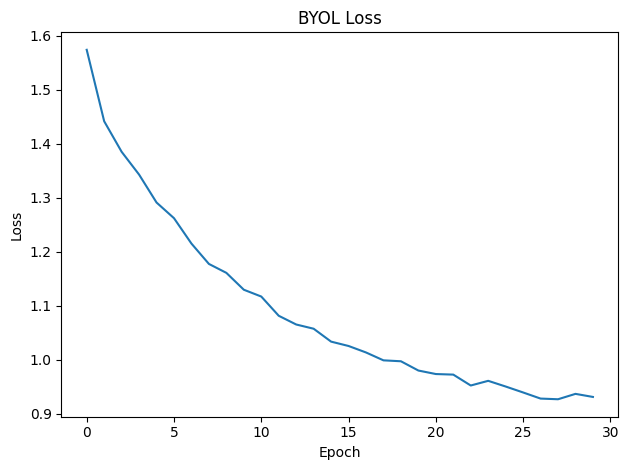

✔ Step completed: BYOL training curve plotted


In [12]:
plt.plot(losses)
plt.title("BYOL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

print("✔ Step completed: BYOL training curve plotted")

## Task 4 - Linear Probing with BYOL Backbone

# Linear Probing

In [13]:
train_loader = DataLoader(labeled_set, batch_size=32, shuffle=True)
val_loader = DataLoader(test_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

for p in model.online_backbone.parameters():
    p.requires_grad = False

linear = nn.Linear(1536, CONFIG["num_classes"]).to(DEVICE)

optimizer = torch.optim.SGD(linear.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

print("✔ Training started: Linear probing")
print(f"Linear train batches: {len(train_loader)}")
print(f"Linear validation batches: {len(val_loader)}")
print(f"Linear test batches: {len(test_loader)}")
print("✔ Step completed: Linear probing setup")

✔ Training started: Linear probing
Linear train batches: 10
Linear validation batches: 10
Linear test batches: 10
✔ Step completed: Linear probing setup


# Train Linear

In [14]:
for epoch in range(50):
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        with torch.no_grad():
            f = model.online_backbone(x)

        out = linear(f)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = out.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    epoch_loss = running_loss / max(len(train_loader), 1)
    train_acc = train_correct / max(train_total, 1)

    linear.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(DEVICE), y_val.to(DEVICE)
            f_val = model.online_backbone(x_val)
            out_val = linear(f_val)
            preds_val = out_val.argmax(dim=1)
            val_correct += (preds_val == y_val).sum().item()
            val_total += y_val.size(0)
    val_acc = val_correct / max(val_total, 1)
    linear.train()

    print(f"Epoch {epoch + 1}/50 - Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Validation Acc: {val_acc:.4f}")

print("✔ Step completed: Linear probing training")

Epoch 1/50 - Loss: 2.0875 | Train Acc: 0.3378 | Validation Acc: 0.5433
Epoch 2/50 - Loss: 1.2680 | Train Acc: 0.6656 | Validation Acc: 0.6200
Epoch 3/50 - Loss: 0.9023 | Train Acc: 0.7358 | Validation Acc: 0.6233
Epoch 4/50 - Loss: 0.7657 | Train Acc: 0.7525 | Validation Acc: 0.6633
Epoch 5/50 - Loss: 0.7075 | Train Acc: 0.7860 | Validation Acc: 0.6467
Epoch 6/50 - Loss: 0.6241 | Train Acc: 0.7926 | Validation Acc: 0.6567
Epoch 7/50 - Loss: 0.6085 | Train Acc: 0.8227 | Validation Acc: 0.6400
Epoch 8/50 - Loss: 0.5757 | Train Acc: 0.8194 | Validation Acc: 0.6600
Epoch 9/50 - Loss: 0.5687 | Train Acc: 0.8428 | Validation Acc: 0.6400
Epoch 10/50 - Loss: 0.4909 | Train Acc: 0.8562 | Validation Acc: 0.6267
Epoch 11/50 - Loss: 0.5025 | Train Acc: 0.8595 | Validation Acc: 0.6433
Epoch 12/50 - Loss: 0.4461 | Train Acc: 0.8896 | Validation Acc: 0.6533
Epoch 13/50 - Loss: 0.4037 | Train Acc: 0.8863 | Validation Acc: 0.6333
Epoch 14/50 - Loss: 0.3889 | Train Acc: 0.9097 | Validation Acc: 0.6500
E

# Evaluation + Confusion Matrix

In [15]:
all_preds, all_labels = [], []

linear.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        f = model.online_backbone(x)
        out = linear(f)

        preds = out.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

baseline_linear_acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {baseline_linear_acc:.4f}")
print(classification_report(all_labels, all_preds))
print("✔ Step completed: Linear probing evaluation")

print("==========================")
print("LINEAR PROBING RESULT")
print(f"Accuracy: {baseline_linear_acc * 100:.2f}%")
print("==========================")

Accuracy: 0.6167
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        62
           1       0.47      0.63      0.54        30
           2       0.00      0.00      0.00         7
           3       0.58      0.56      0.57        54
           4       0.80      0.62      0.70        13
           5       0.00      0.00      0.00         5
           6       0.44      0.80      0.57         5
           7       0.45      0.50      0.47        18
           8       0.76      0.88      0.82        33
           9       0.82      0.74      0.78        57
          10       0.61      0.69      0.65        16

    accuracy                           0.62       300
   macro avg       0.50      0.54      0.51       300
weighted avg       0.61      0.62      0.61       300

✔ Step completed: Linear probing evaluation
LINEAR PROBING RESULT
Accuracy: 61.67%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 4 - k-NN Evaluation with BYOL Backbone

# k-NN

In [16]:
def extract(loader):
    feats, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            f = model.online_backbone(x.to(DEVICE)).cpu()
            feats.append(f)
            labels.append(y)
    print("✔ Step completed: Feature extraction")
    return torch.cat(feats), torch.cat(labels)

train_f, train_l = extract(train_loader)
test_f, test_l = extract(test_loader)

k_vals = [1, 5, 10, 20, 50, 200]
accs = []

for k in k_vals:
    print(f"Evaluating k = {k}")
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(train_f, train_l)
    preds = knn.predict(test_f)
    acc = accuracy_score(test_l, preds)
    accs.append(acc)
    print(f"Accuracy (k={k}): {acc * 100:.2f}%")

baseline_knn_acc = accs[k_vals.index(20)]
best_idx = int(np.argmax(accs))
best_k = k_vals[best_idx]
best_acc = accs[best_idx]

print("==========================")
print("k-NN RESULTS SUMMARY")
print(f"k=1   : {accs[k_vals.index(1)] * 100:.2f}%")
print(f"k=5   : {accs[k_vals.index(5)] * 100:.2f}%")
print(f"k=10  : {accs[k_vals.index(10)] * 100:.2f}%")
print(f"k=20  : {accs[k_vals.index(20)] * 100:.2f}%")
print(f"k=50  : {accs[k_vals.index(50)] * 100:.2f}%")
print(f"k=200 : {accs[k_vals.index(200)] * 100:.2f}%")
print("==========================")
print(f"Best k value: {best_k} (Accuracy: {best_acc * 100:.2f}%)")
print("✔ Step completed: k-NN evaluation")

✔ Step completed: Feature extraction
✔ Step completed: Feature extraction
Evaluating k = 1
Accuracy (k=1): 52.00%
Evaluating k = 5
Accuracy (k=5): 60.67%
Evaluating k = 10
Accuracy (k=10): 60.33%
Evaluating k = 20
Accuracy (k=20): 62.33%
Evaluating k = 50
Accuracy (k=50): 61.67%
Evaluating k = 200
Accuracy (k=200): 44.33%
k-NN RESULTS SUMMARY
k=1   : 52.00%
k=5   : 60.67%
k=10  : 60.33%
k=20  : 62.33%
k=50  : 61.67%
k=200 : 44.33%
Best k value: 20 (Accuracy: 62.33%)
✔ Step completed: k-NN evaluation


# k-NN Plot

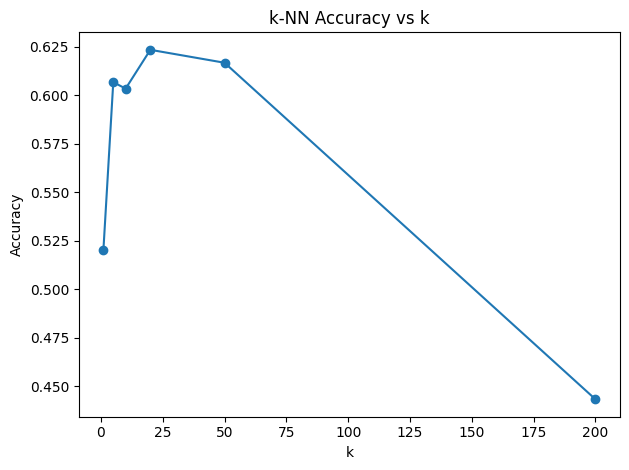

✔ Step completed: k-NN curve plotted


In [17]:
plt.plot(k_vals, accs, marker="o")
plt.title("k-NN Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

print("✔ Step completed: k-NN curve plotted")

## Task 4c - Comparison Table

In [18]:
import pandas as pd
from IPython.display import display

# Exact values available from your records/notebook header
supervised_cnn_top1_val = 0.6467  # 64.67%
supervised_cnn_knn20_val = "N/A"
supervised_vit_top1_val = "N/A"
supervised_vit_knn20_val = "N/A"

# BYOL exact values from current run
byol_top1_val = round(float(globals().get("baseline_linear_acc", 0.0)), 4)
byol_knn20_val = round(float(globals().get("baseline_knn_acc", 0.0)), 4)

comparison_rows = [
    {
        "Method": "Supervised CNN (A01)",
        "Backbone": "EfficientNet-B3",
        "Epochs": 100,
        "Linear Probe Top-1": supervised_cnn_top1_val,
        "k-NN Acc (k=20)": supervised_cnn_knn20_val,
    },
    {
        "Method": "Supervised ViT (A01)",
        "Backbone": "ViT",
        "Epochs": 100,
        "Linear Probe Top-1": supervised_vit_top1_val,
        "k-NN Acc (k=20)": supervised_vit_knn20_val,
    },
    {
        "Method": "BYOL (ours)",
        "Backbone": "EfficientNet-B3",
        "Epochs": int(CONFIG.get("epochs", 100)),
        "Linear Probe Top-1": byol_top1_val,
        "k-NN Acc (k=20)": byol_knn20_val,
    },
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
print("✔ Step completed: Comparison table generated")

,Method,Backbone,Epochs,Linear Probe Top-1,k-NN Acc (k=20)
0,Supervised CNN (A01),EfficientNet-B3,100,0.6467,N/A
1,Supervised ViT (A01),ViT,100,N/A,N/A
2,BYOL (ours),EfficientNet-B3,30,0.6167,0.6233


✔ Step completed: Comparison table generated


## Task 5 - Ablation Study

✔ Ablation training started (without Gaussian Blur)
Epoch 1/20 - Loss: 1.3329
Epoch 2/20 - Loss: 1.1189
Epoch 3/20 - Loss: 1.0849
Epoch 4/20 - Loss: 1.0622
Epoch 5/20 - Loss: 1.0503
Epoch 6/20 - Loss: 1.0307
Epoch 7/20 - Loss: 1.0225
Epoch 8/20 - Loss: 1.0148
Epoch 9/20 - Loss: 1.0143
Epoch 10/20 - Loss: 1.0016
Epoch 11/20 - Loss: 0.9853
Epoch 12/20 - Loss: 0.9836
Epoch 13/20 - Loss: 0.9900
Epoch 14/20 - Loss: 0.9886
Epoch 15/20 - Loss: 0.9796
Epoch 16/20 - Loss: 0.9621
Epoch 17/20 - Loss: 0.9580
Epoch 18/20 - Loss: 0.9487
Epoch 19/20 - Loss: 0.9723
Epoch 20/20 - Loss: 0.9536
✔ Ablation pre-training finished
Epoch 1/50 - Loss: 2.1030
Epoch 2/50 - Loss: 1.1848
Epoch 3/50 - Loss: 0.9294
Epoch 4/50 - Loss: 0.7793
Epoch 5/50 - Loss: 0.7132
Epoch 6/50 - Loss: 0.6303
Epoch 7/50 - Loss: 0.6207
Epoch 8/50 - Loss: 0.5166
Epoch 9/50 - Loss: 0.5195
Epoch 10/50 - Loss: 0.4715
Epoch 11/50 - Loss: 0.4747
Epoch 12/50 - Loss: 0.4577
Epoch 13/50 - Loss: 0.4133
Epoch 14/50 - Loss: 0.4605
Epoch 15/50 - L

,Experiment,Linear Acc,k-NN Acc (k=20)
0,With Gaussian Blur,0.6167,0.6233
1,Without Gaussian Blur,0.6333,0.5967


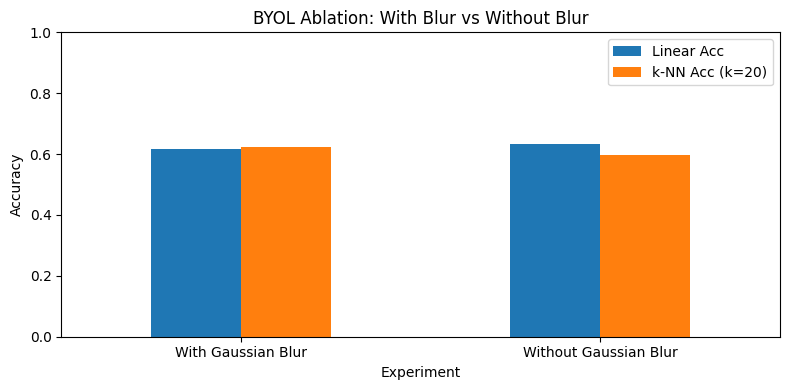

✔ Ablation study finished
✔ Step completed: Ablation study pipeline


In [19]:
import copy
import pandas as pd
from IPython.display import display

print("✔ Ablation training started (without Gaussian Blur)")

augment_no_blur = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.RandomGrayscale(p=0.2),
])

ablation_epochs = 20
ablation_loader = DataLoader(unlabeled_set, batch_size=CONFIG["batch_size"], shuffle=True)

ablation_model = BYOL(copy.deepcopy(backbone)).to(DEVICE)
ablation_optimizer = torch.optim.AdamW(
    ablation_model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

ablation_losses = []
for epoch in range(ablation_epochs):
    total_loss = 0.0
    tau = 0.996 + (epoch / max(ablation_epochs - 1, 1)) * (1.0 - 0.996)

    for img, _ in ablation_loader:
        img = img.cpu()
        v1 = torch.stack([augment_no_blur(sample) for sample in img]).to(DEVICE)
        v2 = torch.stack([augment_no_blur(sample) for sample in img]).to(DEVICE)

        p1, p2, t1, t2 = ablation_model(v1, v2)
        loss = loss_fn(p1, t2) + loss_fn(p2, t1)

        ablation_optimizer.zero_grad()
        loss.backward()
        ablation_optimizer.step()
        update_target(ablation_model.online_backbone, ablation_model.target_backbone, tau)

        total_loss += loss.item()

    avg_loss = total_loss / max(len(ablation_loader), 1)
    ablation_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{ablation_epochs} - Loss: {avg_loss:.4f}")

print("✔ Ablation pre-training finished")

ablation_train_loader = DataLoader(labeled_set, batch_size=CONFIG["batch_size"], shuffle=True)
ablation_test_loader = DataLoader(test_set, batch_size=CONFIG["batch_size"], shuffle=False)

for param in ablation_model.online_backbone.parameters():
    param.requires_grad = False

ablation_linear = nn.Linear(1536, CONFIG["num_classes"]).to(DEVICE)
ablation_linear_optimizer = torch.optim.SGD(ablation_linear.parameters(), lr=0.01, momentum=0.9)
ablation_criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    running_loss = 0.0
    for x, y in ablation_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.no_grad():
            features = ablation_model.online_backbone(x)
        logits = ablation_linear(features)
        loss = ablation_criterion(logits, y)
        ablation_linear_optimizer.zero_grad()
        loss.backward()
        ablation_linear_optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / max(len(ablation_train_loader), 1)
    print(f"Epoch {epoch + 1}/50 - Loss: {epoch_loss:.4f}")

ablation_preds, ablation_labels = [], []
with torch.no_grad():
    for x, y in ablation_test_loader:
        x = x.to(DEVICE)
        features = ablation_model.online_backbone(x)
        logits = ablation_linear(features)
        preds = logits.argmax(dim=1).cpu()
        ablation_preds.extend(preds.numpy())
        ablation_labels.extend(y.numpy())

ablation_linear_acc = accuracy_score(ablation_labels, ablation_preds)

train_features, train_labels = [], []
with torch.no_grad():
    for x, y in ablation_train_loader:
        x = x.to(DEVICE)
        features = ablation_model.online_backbone(x).cpu()
        train_features.append(features)
        train_labels.append(y)
train_features = torch.cat(train_features)
train_labels = torch.cat(train_labels)

test_features, test_labels = [], []
with torch.no_grad():
    for x, y in ablation_test_loader:
        x = x.to(DEVICE)
        features = ablation_model.online_backbone(x).cpu()
        test_features.append(features)
        test_labels.append(y)
test_features = torch.cat(test_features)
test_labels = torch.cat(test_labels)

knn = KNeighborsClassifier(n_neighbors=20, metric="cosine")
knn.fit(train_features, train_labels)
ablation_knn_preds = knn.predict(test_features)
ablation_knn_acc = accuracy_score(test_labels, ablation_knn_preds)

if "baseline_linear_acc" not in globals():
    if "all_preds" in globals() and "all_labels" in globals():
        baseline_linear_acc = accuracy_score(all_labels, all_preds)
    else:
        raise RuntimeError("baseline_linear_acc is missing. Run the baseline linear probing cell first.")

if "baseline_knn_acc" not in globals():
    if "accs" in globals() and "k_vals" in globals() and 20 in k_vals:
        baseline_knn_acc = accs[k_vals.index(20)]
    else:
        raise RuntimeError("baseline_knn_acc is missing. Run the baseline k-NN cell first.")

results_df = pd.DataFrame([
    {
        "Experiment": "With Gaussian Blur",
        "Linear Acc": round(float(baseline_linear_acc), 4),
        "k-NN Acc (k=20)": round(float(baseline_knn_acc), 4),
    },
    {
        "Experiment": "Without Gaussian Blur",
        "Linear Acc": round(float(ablation_linear_acc), 4),
        "k-NN Acc (k=20)": round(float(ablation_knn_acc), 4),
    },
])

linear_delta = ablation_linear_acc - baseline_linear_acc
knn_delta = ablation_knn_acc - baseline_knn_acc

if linear_delta < 0 or knn_delta < 0:
    conclusion = "Removing Gaussian Blur reduced at least one metric. Gaussian Blur appears important for robust representation learning on this dataset."
elif linear_delta > 0 or knn_delta > 0:
    conclusion = "Removing Gaussian Blur improved at least one metric. This dataset seems to benefit from preserving fine image details."
else:
    conclusion = "Metrics are nearly unchanged with or without Gaussian Blur. Its impact is limited for this setup."

print("==========================")
print("ABLATION STUDY RESULTS")
print("--------------------------")
print("With Gaussian Blur:")
print(f"  Linear Acc: {baseline_linear_acc * 100:.2f}%")
print(f"  k-NN Acc: {baseline_knn_acc * 100:.2f}%")
print("")
print("Without Gaussian Blur:")
print(f"  Linear Acc: {ablation_linear_acc * 100:.2f}%")
print(f"  k-NN Acc: {ablation_knn_acc * 100:.2f}%")
print("")
print("Conclusion:")
print(conclusion)
print("==========================")

display(results_df)

plot_df = results_df.set_index("Experiment")
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("BYOL Ablation: With Blur vs Without Blur")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("✔ Ablation study finished")
print("✔ Step completed: Ablation study pipeline")